In [1]:
from src import data_processing
from src import paths
import yaml
import pandas as pd
import statsmodels.api as sm
from src.utils import view_statsmodels_summaries
from src.utils import create_interactive_viewer

import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import os

In [2]:
with open('../src/configs/config.yaml', 'r') as f:
    full_config = yaml.safe_load(f)

final_df = data_processing.get_analysis_ready_df(
    full_config=full_config, use_cache=False, force_refresh=False)
og_df = pd.read_parquet(paths.RAW_DATA_DIR/'BARTER_DEALS.parquet')

Loading files for analysis barter_deals
🐢 Running full processing pipeline...


ValueError: No objects to concatenate

In [3]:
final_df

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,top_k_logits,constrained_logits,top_k_tokens,constrained_tokens,sorted_tokens,sorted_logits,mean_rating,mode_rating,entropy,normalized_entropy
0,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[37.44402313232422, 32.46244430541992, 26.165...","[[22.272668838500977, 24.347896575927734, 32.4...","[[4, 3, âģ, 5, ï¸ı, 2, âĳ, 1, 6, âĤ, 8, 7, **,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[22.272668838500977, 24.347896575927734, 32.4...",3.993179,4.0,0.040829,0.029452
1,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[34.1934928894043, 32.436946868896484, 25.588...","[[20.866113662719727, 25.588775634765625, 34.1...","[[3, 4, 2, ï¸ı, âģ, 5, **, 8, âĳ, 1, 7, Â³, 6,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[20.866113662719727, 25.588775634765625, 34.1...",3.147041,3.0,0.419342,0.302492
2,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[33.35210418701172, 31.47815704345703, 25.473...","[[19.44389533996582, 22.37546157836914, 31.478...","[[4, 3, ï¸ı, âģ, 5, 2, **, âŃĲ, 8, 7, âĳ, Ġ**,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[19.44389533996582, 22.37546157836914, 31.478...",3.866884,4.0,0.392396,0.283054
3,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[36.0689811706543, 34.6262092590332, 25.75268...","[[21.82582664489746, 25.752683639526367, 36.06...","[[3, 4, 2, ï¸ı, 5, âģ, Â³, 1, **, 8, 6, 7, âĤ,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[21.82582664489746, 25.752683639526367, 36.06...",3.191083,3.0,0.488141,0.352119
4,0,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",019689e5-f489-00c8-8c26-06b3ea0961a5,uploads/deals/019689e5-f54b-ffff-dbed-637e9d2a...,5000,None,2023-11-28 14:59:51.626780,2023-11-28 14:59:51.626780,2025-05-01 03:31:11.600095,NaT,...,"[[49.060035705566406, 38.97117233276367, 31.23...","[[49.060035705566406, 38.97117233276367, 31.23...","[[1, 2, 3, 0, Â¹, 4, âĤģ, 5, âĳ, Â½, Û, 6, **,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[49.060035705566406, 38.97117233276367, 31.23...",1.000042,1.0,0.000461,0.000332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,0,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip...",019689e2-d879-00c8-0783-bbe41f1a45ac,uploads/deals/019689e2-d940-ffff-9b7a-7bf93905...,5000,None,2025-03-04 16:58:29.302085,2025-03-04 16:58:29.302085,2025-05-01 03:27:47.664621,NaT,...,"[[39.8774299621582, 34.90399169921875, 28.7510...","[[26.885190963745117, 34.90399169921875, 39.87...","[[3, 2, 4, 1, ï¸ı, 5, Â³, 7, 8, 6, Ġ**, 0, Û, ...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[26.885190963745117, 34.90399169921875, 39.87...",2.993138,3.0,0.041280,0.029777
3996,27,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019689e2-66eb-00c8-ddf3-ca9a3d063b80,uploads/deals/019689e2-67b0-ffff-c05b-fbc204bf...,2500,None,2025-02-26 21:55:50.754848,2025-02-26 21:55:50.754848,2025-10-28 10:50:43.934652,NaT,...,"[[36.37974548339844, 35.53034591674805, 33.645...","[[33.64588165283203, 35.53034591674805, 36.379...","[[3, 2, 1, 4, 5, ï¸ı, 0, âĳ, Ġ**, Â², Â³, 6, Û...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[33.64588165283203, 35.53034591674805, 36.379...",2.627435,3.0,0.768372,0.554263
3997,27,"[{'id': 23, 'name': 'Food', 

In [4]:
active_analysis = full_config['active_analysis']
model_vars = full_config['analyses'][active_analysis]['model_vars']
experimental_groups = model_vars['experimental_groups']

In [5]:
final_df.groupby(experimental_groups).count()

applicants_applications_count  \
model_name                  prompt_id    dimension_name                                           
Qwen/Qwen3-4B-Instruct-2507 539ae380307e Call-to-action strength                           1000   
                                         Clarity                                           1000   
                                         Persuasiveness                                    1000   
                            9e5546bfa1   quality                                           1000   

                                                                  content_types  \
model_name                  prompt_id    dimension_name                           
Qwen/Qwen3-4B-Instruct-2507 539ae380307e Call-to-action strength            998   
                                         Clarity                            998   
                                         Persuasiveness                     998   
                            9e5546bfa1   quality                            998   

                                                                  deal_id  \
model_name                  prompt_id    dimension_name                     
Qwen/Qwen3-4B-Instruct-2507 539ae380307e Call-to-action strength     1000   
                                         Clarity                     1000   
                                         Persuasiveness              1000   
                            9e5546bfa1   quality                     1000   

                                                                  main_image  \
model_name                  prompt_id    dimension_name                        
Qwen/Qwen3-4B-Instruct-2507 539ae380307e Call-to-action strength        1000   
                                         Clarity                        1000   
                                         Persuasiveness                 1000   
                            9e5546bfa1   quality                        1000   

                                                                  min_social_media_followers  \
model_name                  prompt_id    dimension_name                                        
Qwen/Qwen3-4B-Instruct-2507 539ae380307e Call-to-action strength                        1000   
                                         Clarity                                        1000   
                                         Persuasiveness                                 1000   
                            9e5546bfa1   quality                                        1000   

                                                                  deal_tags  \
model_name                  prompt_id    dimension_name                       
Qwen/Qwen3-4B-Instruct-2507 539ae380307e Call-to-action strength          0   
                                         Clarity                          0   
                                         Persuasiveness                   0   
                            9e5546bfa1   quality                          0   

                                                                  live_since  \
model_name                  prompt_id    dimension_name                        
Qwen/Qwen3-4B-Instruct-2507 539ae380307e Call-to-action strength         825   
                                         Clarity                         825   
                                         Persuasiveness                  825   
                            9e5546bfa1   quality                         825   

                                                                  created_at  \
model_name                  prompt_id    dimension_name                        
Qwen/Qwen3-4B-Instruct-2507 539ae380307e Call-to-action strength        1000   
                                         Clarity                        1000   
                                         Persuasiveness                 1000   
                            9e5546bfa1   quality                        1000   

              

In [6]:
df = final_df.copy()

# Data cleaning

In [7]:
og_df.isna().sum()

applicants_applications_count       0
content_types                      11
deal_id                             0
main_image                          0
min_social_media_followers          0
deal_tags                        5111
live_since                        908
created_at                          0
updated_at                          0
deleted_at                       4426
id                                  0
partner_id                          0
deal_title                          0
deal_text                           0
creators_requirement                0
hash_tags                           0
status                              0
deal_value                         72
go_live_at                        252
live_until                       4419
deal_type                           0
images                             31
business_tone                    5111
ai_enhanced                         0
accepts_international               0
accepted_countries                  0
social_requi

In [8]:
b = og_df[~og_df.deleted_at.isna()]
b

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,legacy_id,tags,gender,featured_image,company_id,test_nr_of_apps,update_at_date,diff,apps_after_7_days,apps_after_7_days_OLD
20,0,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",0196cf30-3d9e-00c8-45de-a6091919cc67,,1500,None,NaT,2025-05-14 14:26:07.390204,2025-05-14 14:38:34.607315,2025-05-15 09:33:30.588079+00:00,...,NaN,None,None,None,None,0,2025-05-14,0,0,NaN
23,0,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",0196cf35-c5d6-00c8-4d97-bbfef60b2cf5,,2500,None,NaT,2025-05-14 14:32:09.942486,2025-05-14 14:32:15.868080,2025-05-14 14:35:11.325650+00:00,...,NaN,None,None,None,None,0,2025-05-14,0,0,NaN
24,65,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}, ...",019689e5-c8c2-00c8-79f3-9992362edeea,uploads/deals/019689e5-c976-ffff-edd8-529b3e62...,5000,None,NaT,2023-11-22 12:13:25.712323,2025-05-01 03:31:00.674606,2024-02-10 14:35:49.163784+00:00,...,468.0,None,None,None,None,65,2025-05-01,0,0,NaN
33,6,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019689e3-770b-00c8-d2ee-83252084a97a,uploads/deals/019689e3-77aa-ffff-9af7-e4cde670...,2500,None,NaT,2024-02-16 13:13:22.821687,2025-05-01 03:28:28.371244,2024-02-24 14:08:58.711124+00:00,...,660.0,None,None,None,None,6,2025-05-01,0,0,NaN
43,0,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",019689e2-4cfe-00c8-3431-cc40ca55bde0,uploads/deals/019689e2-4db3-ffff-cf7e-29abc068...,5000,None,NaT,2023-12-18 08:49:13.007895,2025-05-01 03:27:12.084951,2023-12-21 10:32:49.679705+00:00,...,539.0,None,None,None,None,0,2025-05-01,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3752,10,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e5-5467-00c8-2313-73cc8fa9d396,uploads/deals/019689e5-550c-ffff-e4ca-827b5ab9...,5000,None,NaT,2024-03-28 09:11:35.076057,2025-05-01 03:30:30.900280,2024-04-29 08:28:13.798820+00:00,...,895.0,None,None,None,None,10,2025-05-01,0,0,NaN
3768,16,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e5-3460-00c8-9c3e-70c3c96c58a8,uploads/deals/019689e5-3501-ffff-7828-d91bff66...,5000,None,NaT,2024-03-23 18:20:29.924824,2025-05-01 03:30:22.297392,2024-04-03 09:25:23.559215+00:00,...,858.0,None,None,None,None,16,2025-05-01,0,0,0.0
3769,4,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip...",019689e5-17b9-00c8-b740-b33d1546b99b,uploads/deals/019689e5-1e87-ffff-c2b5-c4ba27f1...,5000,None,NaT,2024-10-14 09:44:45.892968,2025-05-01 03:30:16.674483,2024-12-06 14:47:39.629223+00:00,...,1861.0,None,None,None,None,4,2025-05-01,0,0,0.0
3806,16,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019689e5-c484-00c8-1796-a40189fb5d24,uploads/deals/019689e5-c647-ffff-4069-085db271...,2500,None,NaT,2024-10-21 12:55:38.086083,2025-05-01 03:30:59.492880,2024-10-28 14:41:32.444328+00:00,...,1921.0,None,None,None,None,16,2025-05-01,0,0,15.0


I have noticed that sometimes there is a big discrepancy between the nr. of people that registered in the first 7 days and the total number of applicants. This might have something to do with the way that I compute the nr. of apps after 7 days. I will need to check for specific deals where $diff$ is big, and see why I find few or no applications after 7 days. 

In [ ]:
og_df['diff'] = og_df['applicants_applications_count'] - \
    og_df['apps_after_7_days']
bigdiff = og_df[og_df['diff'] > 200]
bigdiff

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,legacy_id,tags,gender,featured_image,company_id,test_nr_of_apps,update_at_date,diff,apps_after_7_days,apps_after_7_days_OLD
34,382,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e5-5a44-00c8-34b6-521692d697e8,uploads/deals/019689e5-5afd-ffff-cbf7-5c75751a...,2500,None,2023-11-06 19:01:40.630849,2023-11-06 19:01:40.630849,2025-05-01 03:30:32.010040,NaT,...,427.0,None,None,None,None,382,2025-05-01,356,26,26.0
79,668,"[{'id': 38, 'name': 'Music', 'slug': 'Music-No...",019689e5-7391-00c8-df2d-4b1be8c26296,uploads/deals/019689e5-7437-ffff-c6ae-d33f6c7f...,2500,None,2024-04-03 08:51:20.713500,2024-04-03 08:51:20.713500,2025-06-30 09:34:41.008144,NaT,...,904.0,None,None,None,None,668,2025-06-30,600,68,72.0
81,377,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip...",019689e4-eb07-00c8-3427-16787d41c471,uploads/deals/019689e4-ec3e-ffff-a1ed-509372eb...,5000,None,2025-01-16 10:26:27.549317,2025-01-16 10:26:27.549317,2025-05-01 03:30:03.775698,NaT,...,2922.0,None,None,None,None,377,2025-05-01,302,75,75.0
98,462,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip...",019689e4-ef20-00c8-da5f-24f0ab38d2ba,uploads/deals/019689e4-f038-ffff-ba91-38ba1802...,2500,None,2024-10-11 21:50:11.868064,2024-10-11 21:50:11.868064,2025-05-01 03:30:04.796789,NaT,...,1850.0,None,None,None,None,462,2025-05-01,398,64,64.0
108,540,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019689e5-8c20-00c8-6af0-91f6bc745e40,uploads/deals/019689e5-8c82-ffff-05ca-3cfd45da...,5000,None,2024-04-04 15:42:55.867443,2024-04-04 15:42:55.867443,2025-05-01 03:30:44.708708,NaT,...,916.0,None,None,None,None,540,2025-05-01,473,67,80.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4684,758,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip...",019689e6-6487-00c8-17e9-62570a38ad86,uploads/deals/019689e6-65ad-ffff-06e6-7b7bb6dd...,2500,None,2025-02-14 10:26:57.293626,2025-02-14 10:26:57.293626,2025-09-15 04:00:06.952349,NaT,...,3354.0,None,None,None,None,758,2025-09-15,600,158,5.0
4941,411,"[{'id': 40, 'name': 'Drinks', 'slug': 'Champag...",019689e4-6933-00c8-d264-203a3d674556,uploads/deals/019689e4-69e5-ffff-7dcb-43d7bf4f...,2500,None,2024-03-12 10:22:32.876830,2024-03-12 10:22:32.876830,2025-10-28 10:54:52.068103,NaT,...,778.0,None,None,None,0199f1d4-2259-015e-e3cd-2cc5bc018601,411,2025-10-28,371,40,18.0
4950,332,"[{'id': 22, 'name': 'Travel', 'slug': 'Airplan...",019689e2-7d1c-00c8-8ca0-5700ca5322f9,uploads/deals/019689e2-7dc8-ffff-f351-a25215f6...,2500,None,2024-11-24 10:56:46.807379,2024-11-24 10:56:46.807379,2025-05-01 03:27:24.176386,NaT,...,2329.0,None,None,None,None,332,2025-05-01,276,56,6.0
4955,665,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e3-27f3-00c8-658b-cac4b6a5e165,uploads/deals/019689e3-28e3-ffff-fedb-a326aa6f...,2500,None,2024-12-04 13:48:28.961533,2024-12-04 13:48:28.961533,2025-09-25 04:00:21.828888,NaT,...,2433.0,None,None,None,None,665,2025-09-25,665,0,3.0


In [10]:
a = og_df[og_df['live_since'].isna()]

In [11]:
a.isna().sum()

applicants_applications_count      0
content_types                     10
deal_id                            0
main_image                         0
min_social_media_followers         0
deal_tags                        908
live_since                       908
created_at                         0
updated_at                         0
deleted_at                       226
id                                 0
partner_id                         0
deal_title                         0
deal_text                          0
creators_requirement               0
hash_tags                          0
status                             0
deal_value                         5
go_live_at                       252
live_until                       847
deal_type                          0
images                            31
business_tone                    908
ai_enhanced                        0
accepts_international              0
accepted_countries                 0
social_requirement_type_id        19
p

In [12]:
df.isna().sum()

applicants_applications_count       0
content_types                       8
deal_id                             0
main_image                          0
min_social_media_followers          0
deal_tags                        4000
live_since                        700
created_at                          0
updated_at                          0
deleted_at                       3536
id                                  0
partner_id                          0
deal_title                          0
deal_text                           0
creators_requirement                0
hash_tags                           0
status                              0
deal_value                         20
go_live_at                        284
live_until                       3524
deal_type                           0
images                             20
business_tone                    4000
ai_enhanced                         0
accepts_international               0
accepted_countries                  0
social_requi

In [ ]:
# Drop NA for which there is no model name (for some reason some outputs generated logits but no metadata, TODO: check why)
df = df.dropna(subset=['model_name'])

In [14]:
df

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,top_k_logits,constrained_logits,top_k_tokens,constrained_tokens,sorted_tokens,sorted_logits,mean_rating,mode_rating,entropy,normalized_entropy
0,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[37.44402313232422, 32.46244430541992, 26.165...","[[22.272668838500977, 24.347896575927734, 32.4...","[[4, 3, âģ, 5, ï¸ı, 2, âĳ, 1, 6, âĤ, 8, 7, **,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[22.272668838500977, 24.347896575927734, 32.4...",3.993179,4.0,0.040829,0.029452
1,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[34.1934928894043, 32.436946868896484, 25.588...","[[20.866113662719727, 25.588775634765625, 34.1...","[[3, 4, 2, ï¸ı, âģ, 5, **, 8, âĳ, 1, 7, Â³, 6,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[20.866113662719727, 25.588775634765625, 34.1...",3.147041,3.0,0.419342,0.302492
2,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[33.35210418701172, 31.47815704345703, 25.473...","[[19.44389533996582, 22.37546157836914, 31.478...","[[4, 3, ï¸ı, âģ, 5, 2, **, âŃĲ, 8, 7, âĳ, Ġ**,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[19.44389533996582, 22.37546157836914, 31.478...",3.866884,4.0,0.392396,0.283054
3,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[36.0689811706543, 34.6262092590332, 25.75268...","[[21.82582664489746, 25.752683639526367, 36.06...","[[3, 4, 2, ï¸ı, 5, âģ, Â³, 1, **, 8, 6, 7, âĤ,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[21.82582664489746, 25.752683639526367, 36.06...",3.191083,3.0,0.488141,0.352119
4,0,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",019689e5-f489-00c8-8c26-06b3ea0961a5,uploads/deals/019689e5-f54b-ffff-dbed-637e9d2a...,5000,None,2023-11-28 14:59:51.626780,2023-11-28 14:59:51.626780,2025-05-01 03:31:11.600095,NaT,...,"[[49.060035705566406, 38.97117233276367, 31.23...","[[49.060035705566406, 38.97117233276367, 31.23...","[[1, 2, 3, 0, Â¹, 4, âĤģ, 5, âĳ, Â½, Û, 6, **,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[49.060035705566406, 38.97117233276367, 31.23...",1.000042,1.0,0.000461,0.000332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,0,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip...",019689e2-d879-00c8-0783-bbe41f1a45ac,uploads/deals/019689e2-d940-ffff-9b7a-7bf93905...,5000,None,2025-03-04 16:58:29.302085,2025-03-04 16:58:29.302085,2025-05-01 03:27:47.664621,NaT,...,"[[39.8774299621582, 34.90399169921875, 28.7510...","[[26.885190963745117, 34.90399169921875, 39.87...","[[3, 2, 4, 1, ï¸ı, 5, Â³, 7, 8, 6, Ġ**, 0, Û, ...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[26.885190963745117, 34.90399169921875, 39.87...",2.993138,3.0,0.041280,0.029777
3996,27,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019689e2-66eb-00c8-ddf3-ca9a3d063b80,uploads/deals/019689e2-67b0-ffff-c05b-fbc204bf...,2500,None,2025-02-26 21:55:50.754848,2025-02-26 21:55:50.754848,2025-10-28 10:50:43.934652,NaT,...,"[[36.37974548339844, 35.53034591674805, 33.645...","[[33.64588165283203, 35.53034591674805, 36.379...","[[3, 2, 1, 4, 5, ï¸ı, 0, âĳ, Ġ**, Â², Â³, 6, Û...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[33.64588165283203, 35.53034591674805, 36.379...",2.627435,3.0,0.768372,0.554263
3997,27,"[{'id': 23, 'name': 'Food', 

In [15]:
print(len(df))
df = df[['test' not in x.lower() for x in df['deal_text']]]
print(len(df))
df = df[['test' not in x.lower() for x in df['deal_title']]]
print(len(df))

4000
3956
3916


In [16]:
print(len(df))
df = df[~df['content_types'].isna()]
print(len(df))

3916
3908


# EDA

In [ ]:
# (Assuming 'df' is your DataFrame)

# 1. Define the keys you will group by
my_group_keys = ['model_name', 'mode_rating', 'prompt_id', 'assistant_prefix']

# 2. Create your dictionary using these keys
rating_dict = {
    k: v[['deal_id', 'deal_title', 'deal_text', 'model_name',
          'mean_rating', 'applicants_applications_count', 'apps_after_7_days']]
    for k, v in df.groupby(my_group_keys)
}

# 3. Call the viewer, passing the *same list*
create_interactive_viewer(rating_dict, my_group_keys)

--- Interactive DataFrame Viewer ---


,deal_id,deal_title,deal_text,model_name,mean_rating,applicants_applications_count,apps_after_7_days
4,019689e5-f489-00c8-8c26-06b3ea0961a5,Promotion clothing,Sharing unique and HQ content photos (one post...,Qwen/Qwen3-4B-Instruct-2507,1.000042,0,0
5,019689e5-f489-00c8-8c26-06b3ea0961a5,Promotion clothing,Sharing unique and HQ content photos (one post...,Qwen/Qwen3-4B-Instruct-2507,1.000001,0,0
6,019689e5-f489-00c8-8c26-06b3ea0961a5,Promotion clothing,Sharing unique and HQ content photos (one post...,Qwen/Qwen3-4B-Instruct-2507,1.000001,0,0
28,019689e4-306b-00c8-d98c-70210470c288,BMM Supplements,We will offer bulk supplements for the right i...,Qwen/Qwen3-4B-Instruct-2507,1.000059,0,0
29,019689e4-306b-00c8-d98c-70210470c288,BMM Supplements,We will offer bulk supplements for the right i...,Qwen/Qwen3-4B-Instruct-2507,1.000007,0,0
...,...,...,...,...,...,...,...
3958,0197ad60-e97b-00c8-c92b-2641560511d7,Kom je een koffie of thee drinken?,In ruil voor een lekker drankje (en in overleg...,Qwen/Qwen3-4B-Instruct-2507,1.000003,5,1
3960,019689e5-81f3-00c8-81b6-bf597386394f,Ajax Amsterdam Canvas kunst,60 x 80 cm canvas doek van Popeyax! Een uniek ...,Qwen/Qwen3-4B-Instruct-2507,1.073781,2,0
3961,019689e5-81f3-00c8-81b6-bf597386394f,Ajax Amsterdam Canvas kunst,60 x 80 cm canvas doek van Popeyax! Een uniek ...,Qwen/Qwen3-4B-Instruct-2507,1.235267,2,0
3962,019689e5-81f3-00c8-81b6-bf597386394f,Ajax Amsterdam Canvas kunst,60 x 80 cm canvas doek van Popeyax! Een uniek ...,Qwen/Qwen3-4B-Instruct-2507,1.000011,2,0


In [18]:
df.groupby(experimental_groups)['mean_rating'].mean()

model_name                   prompt_id     dimension_name         
Qwen/Qwen3-4B-Instruct-2507  539ae380307e  Call-to-action strength    2.414384
                                           Clarity                    2.545865
                                           Persuasiveness             2.625561
                             9e5546bfa1    quality                    2.534659
Name: mean_rating, dtype: float64

First we plot the nr. of observations per rating (mode). A good evaluation model requires good separation. 

- The assistant prefix helps Gemma a lot for the naive prompt, a bit for the BARS prompt.
- The assistant prefix leads to better separation for Qwen with the naive prompt. 
- The BARS prompt leads to higher ratings overall. 

In [19]:
df.groupby(experimental_groups).size()

model_name                   prompt_id     dimension_name         
Qwen/Qwen3-4B-Instruct-2507  539ae380307e  Call-to-action strength    977
                                           Clarity                    977
                                           Persuasiveness             977
                             9e5546bfa1    quality                    977
dtype: int64

C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_13792\3683340649.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(


Text(0.5, 1.03, 'Number of Observations by Binned Rating (grouped by Model / Prompt)')

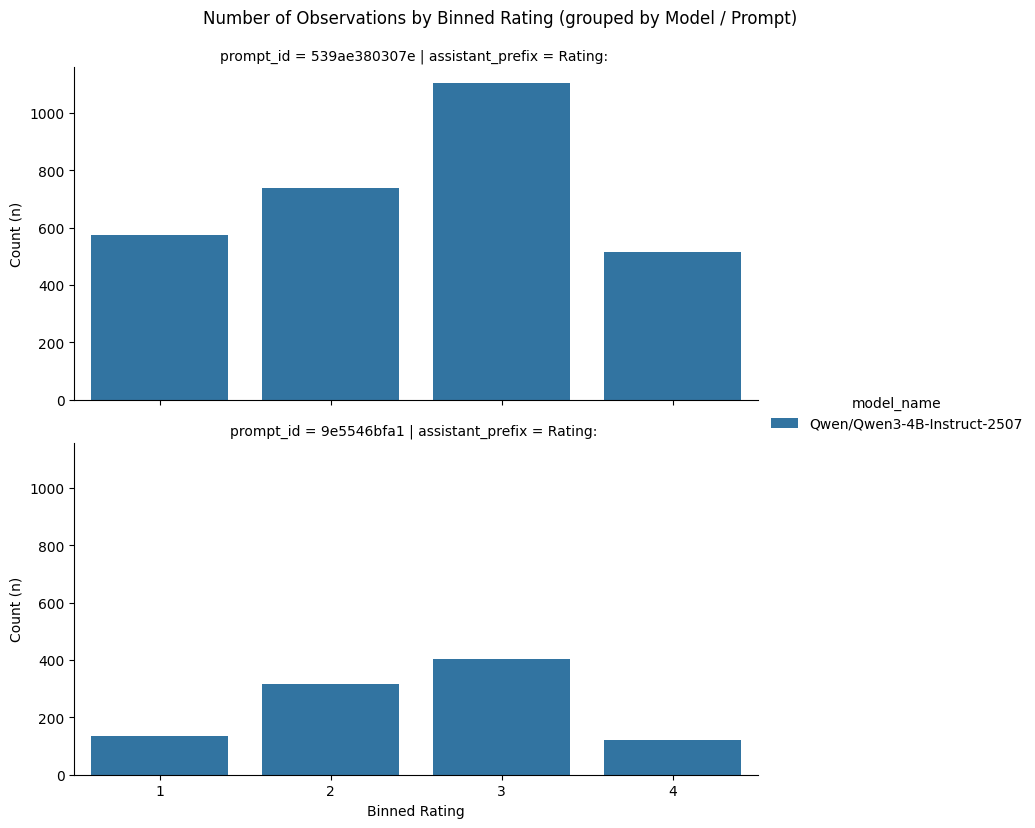

In [ ]:
df_plot = df.copy()

kpi_col = 'apps_after_7_days'
rating_col = 'mode_rating'

# Bin ratings
df_plot['rating_bin'] = df_plot[rating_col].round()

# Ensure all bins appear (even if some combos are missing)
bins = np.arange(int(df_plot['rating_bin'].min()),
                 int(df_plot['rating_bin'].max()) + 1)
df_plot['rating_bin'] = pd.Categorical(
    df_plot['rating_bin'], categories=bins, ordered=True)

# --- 2. Count Plot (number of observations) ---
g = sns.catplot(
    data=df_plot,
    x='rating_bin',
    hue='model_name',
    col='assistant_prefix',
    row='prompt_id',
    kind='count',          # <-- counts observations per category
    height=4,
    aspect=2,
    legend_out=True,
    ci=None
)

# Axis labels and title
g.set_axis_labels('Binned Rating', 'Count (n)')
g.fig.suptitle(
    'Number of Observations by Binned Rating (grouped by Model / Prompt)', y=1.03)

Below we visualise how many creators applied for a deal after 7 days, grouped by LLM rating (mode). We use $estimator=median$, since the mean is sensitive to outliers. We expect that a higher rating leads to more applications. 

Two interesting patterns emerge. For Qwen, the hypothesized pattern holds until $rating=4$. Deals with $rating=5$ has a lower median than $4$. 

Gemma is all over the place. For the naive prompt the nr of applicants can hardly be distinguished based on the rating. For the BARS style prompt it is irregular. 

_Moreover_, we see that the BARS prompt leads Qwen to rate almost every deal 5. This is a huge problem, and shows the sensitivity to prompt design. 

C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_13792\1927751139.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(


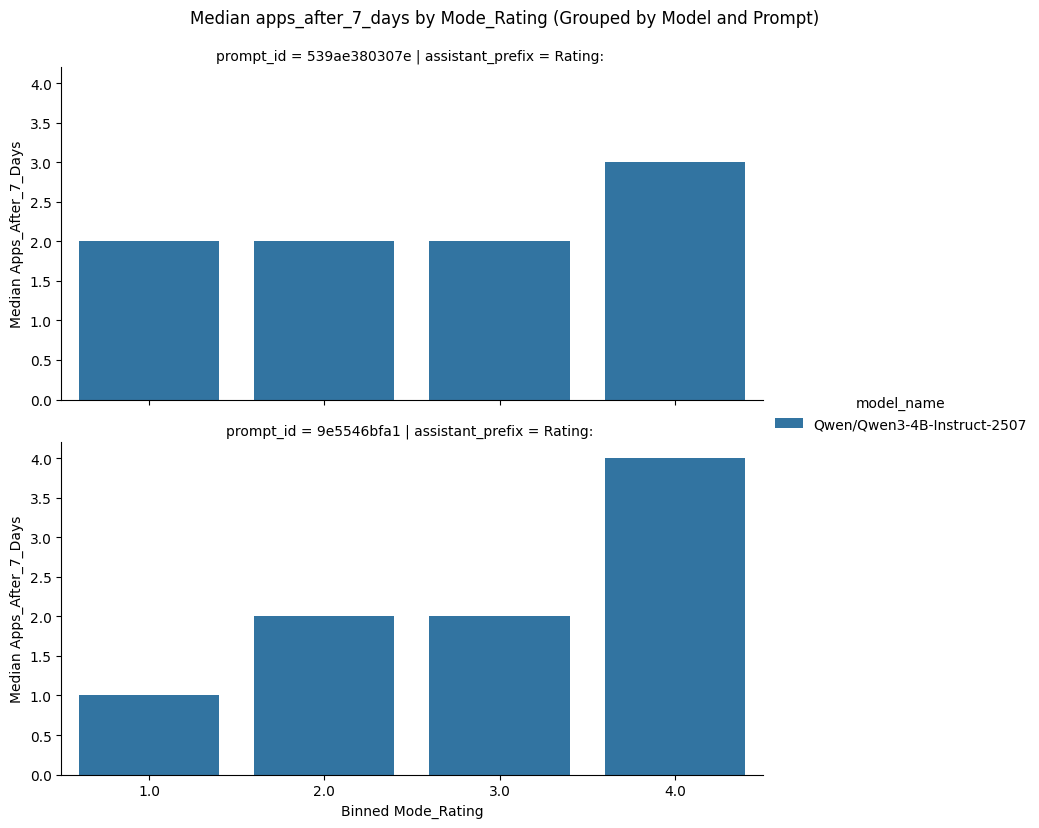

In [ ]:
# --- 1. Prepare Data ---
# Create a copy to avoid modifying the original
df_plot = df.copy()

kpi_col = 'apps_after_7_days'
rating_col = 'mode_rating'

# Create the 'rating_bin' column by rounding the continuous rating
df_plot['rating_bin'] = df_plot[rating_col].round()

# --- 2. Create the Plot ---
# We use sns.catplot (Categorical Plot) as it's a high-level
# interface for creating faceted grids.
g = sns.catplot(
    data=df_plot,
    x='rating_bin',       # X-axis is your binned rating
    y=kpi_col,            # Y-axis is your KPI
    hue='model_name',        # This puts the models side-by-side in one plot
    col='assistant_prefix',
    row='prompt_id',       # This creates the separate plots for each prompt
    kind='bar',           # Specifies the plot type
    estimator=np.median,  # <-- FIX: Use median, which is robust to outliers
    height=4,             # Height of each individual facet
    aspect=2,             # Width-to-height ratio (makes it wider)
    ci=None,              # Turn off confidence intervals for a cleaner look
    # (You can use 'sd' for standard deviation)
    legend_out=True,       # Puts the legend outside the plot
    # estimator = 'mode'
)

# --- 3. Tweak and Save ---
# Add a main title
g.fig.suptitle(
    # <-- FIX: Changed "Mean" to "Median"
    f'Median {kpi_col} by {rating_col.title()} (Grouped by Model and Prompt)',
    y=1.03  # Adjust title position
)

# Set labels for the axes
# <-- FIX: Changed "Mean" to "Median"
g.set_axis_labels(f'Binned {rating_col.title()}', f'Median {kpi_col.title()}')

We consider using a Fixed Effects model of some sort, since we know that unobserved heterogeneity at the company level is very likely related to the evaluations. When applying a random effects (RE) model, we assume that the RE cluster variable is uncorrelated with the predictors. However, we might expect that companies with more baseline applicants also write better marketing copy. 

To analyse which models we can sensibly use, we need to consider whether we have sufficient observations per company. 

In [22]:
# (Assuming 'df' is your DataFrame)

# 1. Define the keys you will group by
my_group_keys = ['model_name', 'mode_rating', 'prompt_id', 'assistant_prefix']

# 2. Create your dictionary using these keys
rating_dict = {
    # k: v[['deal_id', 'deal_title', 'deal_text', 'model_name', 'mean_rating', 'applicants_applications_count']]
    k: pd.DataFrame(v.groupby('partner_id')['mean_rating'].std())
    for k, v in df.groupby(my_group_keys)
}

# 3. Call the viewer, passing the *same list*
create_interactive_viewer(rating_dict, my_group_keys)

--- Interactive DataFrame Viewer ---


,mean_rating
partner_id,
1,1.627327e-02
5,0.000000e+00
6,NaN
15,NaN
22,2.239106e-02
...,...
2198,5.974134e-05
2218,NaN
2338,6.882552e-08


In [23]:
df[df['partner_id'] == 1405]

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,top_k_logits,constrained_logits,top_k_tokens,constrained_tokens,sorted_tokens,sorted_logits,mean_rating,mode_rating,entropy,normalized_entropy
2112,6,"[{'id': 40, 'name': 'Drinks', 'slug': 'Champag...",01975e76-bf2f-00c8-912a-34b64d85bd56,uploads/deals/01975e74-b7e2-ffff-6209-4f012a7e...,2500,None,2025-06-11 10:08:50.151399,2025-06-11 10:08:49.967920,2025-10-28 10:50:13.059109,NaT,...,"[[42.38388442993164, 41.01359558105469, 35.919...","[[35.9195671081543, 41.01359558105469, 42.3838...","[[3, 2, 1, 4, 5, 0, âĳ, Â³, Â², âĤĤ, ï¸ı, 6, Û...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[35.9195671081543, 41.01359558105469, 42.3838...",2.795218,3.0,0.513071,0.370103
2113,6,"[{'id': 40, 'name': 'Drinks', 'slug': 'Champag...",01975e76-bf2f-00c8-912a-34b64d85bd56,uploads/deals/01975e74-b7e2-ffff-6209-4f012a7e...,2500,None,2025-06-11 10:08:50.151399,2025-06-11 10:08:49.967920,2025-10-28 10:50:13.059109,NaT,...,"[[44.14745330810547, 37.54039001464844, 37.010...","[[30.493988037109375, 37.54039001464844, 44.14...","[[3, 2, 4, 1, 5, Â³, 6, 7, 8, âģ, âĳ, ï¸ı, Â¾,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[30.493988037109375, 37.54039001464844, 44.14...",2.999444,3.0,0.016732,0.012070
2114,6,"[{'id': 40, 'name': 'Drinks', 'slug': 'Champag...",01975e76-bf2f-00c8-912a-34b64d85bd56,uploads/deals/01975e74-b7e2-ffff-6209-4f012a7e...,2500,None,2025-06-11 10:08:50.151399,2025-06-11 10:08:49.967920,2025-10-28 10:50:13.059109,NaT,...,"[[45.165138244628906, 39.74689483642578, 37.53...","[[33.09235382080078, 39.74689483642578, 45.165...","[[3, 2, 4, 1, 5, Â³, 6, 7, 8, 0, Â¾, Ù, Â², 9,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[33.09235382080078, 39.74689483642578, 45.165...",2.996060,3.0,0.032593,0.023511
2115,6,"[{'id': 40, 'name': 'Drinks', 'slug': 'Champag...",01975e76-bf2f-00c8-912a-34b64d85bd56,uploads/deals/01975e74-b7e2-ffff-6209-4f012a7e...,2500,None,2025-06-11 10:08:50.151399,2025-06-11 10:08:49.967920,2025-10-28 10:50:13.059109,NaT,...,"[[44.36140823364258, 43.53458023071289, 38.170...","[[38.17043685913086, 44.36140823364258, 43.534...","[[2, 3, 1, 4, 5, 0, âĤĤ, Â², Â³, 6, Û, ï¸ı, âĳ...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[38.17043685913086, 44.36140823364258, 43.534...",2.302464,2.0,0.624373,0.450390


In [24]:
df.groupby(experimental_groups+['partner_id'])['mean_rating']

In [25]:
valc = raw_df['partner_id'].value_counts()

NameError: name 'raw_df' is not defined

In [ ]:
valc[valc > 3].sum() / valc.sum()

np.float64(0.5789473684210527)

In [ ]:
raw_df.groupby(['company_id', 'deal_id']).value_counts()

TypeError: unhashable type: 'numpy.ndarray'

# Feature engineering

In [26]:
df['first_content_type'] = df.content_types.apply(lambda x: x[0]['name'])

# Modeling KPI

In [ ]:
EXPERIMENTAL_GROUPS = ['model_name', 'prompt_id', 'assistant_prefix']
CATEGORICAL_PREDICTORS = ['deal_type', 'first_content_type']
BINARY_PREDICTORS = ['accepts_international']  # Already 0/1 or T/F
NEW_PREDICTOR = 'mean_rating'
TARGET_COL = 'apps_after_7_days'
# df_model_full = df[df.accepted_countries_str == 'NLD'].copy()

df_model_full = df.copy()

In [28]:
df_model_full

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,constrained_logits,top_k_tokens,constrained_tokens,sorted_tokens,sorted_logits,mean_rating,mode_rating,entropy,normalized_entropy,first_content_type
0,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[22.272668838500977, 24.347896575927734, 32.4...","[[4, 3, âģ, 5, ï¸ı, 2, âĳ, 1, 6, âĤ, 8, 7, **,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[22.272668838500977, 24.347896575927734, 32.4...",3.993179,4.0,0.040829,0.029452,Activities
1,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[20.866113662719727, 25.588775634765625, 34.1...","[[3, 4, 2, ï¸ı, âģ, 5, **, 8, âĳ, 1, 7, Â³, 6,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[20.866113662719727, 25.588775634765625, 34.1...",3.147041,3.0,0.419342,0.302492,Activities
2,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[19.44389533996582, 22.37546157836914, 31.478...","[[4, 3, ï¸ı, âģ, 5, 2, **, âŃĲ, 8, 7, âĳ, Ġ**,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[19.44389533996582, 22.37546157836914, 31.478...",3.866884,4.0,0.392396,0.283054,Activities
3,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[21.82582664489746, 25.752683639526367, 36.06...","[[3, 4, 2, ï¸ı, 5, âģ, Â³, 1, **, 8, 6, 7, âĤ,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[21.82582664489746, 25.752683639526367, 36.06...",3.191083,3.0,0.488141,0.352119,Activities
4,0,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",019689e5-f489-00c8-8c26-06b3ea0961a5,uploads/deals/019689e5-f54b-ffff-dbed-637e9d2a...,5000,None,2023-11-28 14:59:51.626780,2023-11-28 14:59:51.626780,2025-05-01 03:31:11.600095,NaT,...,"[[49.060035705566406, 38.97117233276367, 31.23...","[[1, 2, 3, 0, Â¹, 4, âĤģ, 5, âĳ, Â½, Û, 6, **,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[49.060035705566406, 38.97117233276367, 31.23...",1.000042,1.0,0.000461,0.000332,Fashion
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,0,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip...",019689e2-d879-00c8-0783-bbe41f1a45ac,uploads/deals/019689e2-d940-ffff-9b7a-7bf93905...,5000,None,2025-03-04 16:58:29.302085,2025-03-04 16:58:29.302085,2025-05-01 03:27:47.664621,NaT,...,"[[26.885190963745117, 34.90399169921875, 39.87...","[[3, 2, 4, 1, ï¸ı, 5, Â³, 7, 8, 6, Ġ**, 0, Û, ...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[26.885190963745117, 34.90399169921875, 39.87...",2.993138,3.0,0.041280,0.029777,UGC
3996,27,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019689e2-66eb-00c8-ddf3-ca9a3d063b80,uploads/deals/019689e2-67b0-ffff-c05b-fbc204bf...,2500,None,2025-02-26 21:55:50.754848,2025-02-26 21:55:50.754848,2025-10-28 10:50:43.934652,NaT,...,"[[33.64588165283203, 35.53034591674805, 36.379...","[[3, 2, 1, 4, 5, ï¸ı, 0, âĳ, Ġ**, Â², Â³, 6, Û...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[33.64588165283203, 35.53034591674805, 36.379...",2.627435,3.0,0.768372,0.554263,Food
3997,27,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019689e2-66eb-00c8-ddf3-ca9a3d063b80,uploads/deals/019689e2-67b0-ffff-c05b-fbc204bf...,2500,None,2025-02-26 21:55:50.754848,2025-02-26 21:55:50.754848,2025-10-28 10:50:43.934652,NaT,...,"[[30.365764617919922, 35.24386978149414, 36.29...","[[3, 2, 1, 4, ï¸ı, 5, Ġ**, 6, **, 0, Â²

## OLS

In [43]:
df_model_full

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,constrained_logits,top_k_tokens,constrained_tokens,sorted_tokens,sorted_logits,mean_rating,mode_rating,entropy,normalized_entropy,first_content_type
0,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[22.272668838500977, 24.347896575927734, 32.4...","[[4, 3, âģ, 5, ï¸ı, 2, âĳ, 1, 6, âĤ, 8, 7, **,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[22.272668838500977, 24.347896575927734, 32.4...",3.993179,4.0,0.040829,0.029452,Activities
1,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[20.866113662719727, 25.588775634765625, 34.1...","[[3, 4, 2, ï¸ı, âģ, 5, **, 8, âĳ, 1, 7, Â³, 6,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[20.866113662719727, 25.588775634765625, 34.1...",3.147041,3.0,0.419342,0.302492,Activities
2,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[19.44389533996582, 22.37546157836914, 31.478...","[[4, 3, ï¸ı, âģ, 5, 2, **, âŃĲ, 8, 7, âĳ, Ġ**,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[19.44389533996582, 22.37546157836914, 31.478...",3.866884,4.0,0.392396,0.283054,Activities
3,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[21.82582664489746, 25.752683639526367, 36.06...","[[3, 4, 2, ï¸ı, 5, âģ, Â³, 1, **, 8, 6, 7, âĤ,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[21.82582664489746, 25.752683639526367, 36.06...",3.191083,3.0,0.488141,0.352119,Activities
4,0,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",019689e5-f489-00c8-8c26-06b3ea0961a5,uploads/deals/019689e5-f54b-ffff-dbed-637e9d2a...,5000,None,2023-11-28 14:59:51.626780,2023-11-28 14:59:51.626780,2025-05-01 03:31:11.600095,NaT,...,"[[49.060035705566406, 38.97117233276367, 31.23...","[[1, 2, 3, 0, Â¹, 4, âĤģ, 5, âĳ, Â½, Û, 6, **,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[49.060035705566406, 38.97117233276367, 31.23...",1.000042,1.0,0.000461,0.000332,Fashion
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,0,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip...",019689e2-d879-00c8-0783-bbe41f1a45ac,uploads/deals/019689e2-d940-ffff-9b7a-7bf93905...,5000,None,2025-03-04 16:58:29.302085,2025-03-04 16:58:29.302085,2025-05-01 03:27:47.664621,NaT,...,"[[26.885190963745117, 34.90399169921875, 39.87...","[[3, 2, 4, 1, ï¸ı, 5, Â³, 7, 8, 6, Ġ**, 0, Û, ...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[26.885190963745117, 34.90399169921875, 39.87...",2.993138,3.0,0.041280,0.029777,UGC
3996,27,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019689e2-66eb-00c8-ddf3-ca9a3d063b80,uploads/deals/019689e2-67b0-ffff-c05b-fbc204bf...,2500,None,2025-02-26 21:55:50.754848,2025-02-26 21:55:50.754848,2025-10-28 10:50:43.934652,NaT,...,"[[33.64588165283203, 35.53034591674805, 36.379...","[[3, 2, 1, 4, 5, ï¸ı, 0, âĳ, Ġ**, Â², Â³, 6, Û...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[33.64588165283203, 35.53034591674805, 36.379...",2.627435,3.0,0.768372,0.554263,Food
3997,27,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019689e2-66eb-00c8-ddf3-ca9a3d063b80,uploads/deals/019689e2-67b0-ffff-c05b-fbc204bf...,2500,None,2025-02-26 21:55:50.754848,2025-02-26 21:55:50.754848,2025-10-28 10:50:43.934652,NaT,...,"[[30.365764617919922, 35.24386978149414, 36.29...","[[3, 2, 1, 4, ï¸ı, 5, Ġ**, 6, **, 0, Â²

In [ ]:
# --- 3. Run flexible regression for each group ---

# Dictionary to store the fitted models
regression_results = {}

# Group by your experimental categories
grouped_data = df_model_full.groupby(EXPERIMENTAL_GROUPS)

print(f"Total groups to analyze: {len(grouped_data)}")

for group_name, group_df in grouped_data:
    print(f"\n--- Analyzing Group: {group_name} ---")

    # --- 1. Define predictors (X) ---

    # This list will hold all our predictor dataframes
    predictor_dfs = []

    # A. Add continuous/binary predictors (if any)
    # Combine the lists. If one is empty, this still works.
    numeric_predictors = [NEW_PREDICTOR] + BINARY_PREDICTORS

    if numeric_predictors:  # Only add if the list is not empty
        X_numeric = group_df[numeric_predictors].copy()

        # --- FLEXIBLE CONVERSION ---
        # Convert all binary columns to int (if any exist)
        for col in BINARY_PREDICTORS:
            if col in X_numeric.columns:
                X_numeric[col] = X_numeric[col].astype(int)

        predictor_dfs.append(X_numeric)

    # B. Add categorical dummies (if any)
    if CATEGORICAL_PREDICTORS:  # Only run if the list is not empty
        X_dummies = pd.get_dummies(
            group_df[CATEGORICAL_PREDICTORS],
            drop_first=True,
            dtype=int
        )
        predictor_dfs.append(X_dummies)

    # C. Check if we have any predictors at all
    if not predictor_dfs:
        print(f"Skipping group {group_name}: No predictors specified.")
        continue

    # D. Combine all predictor dataframes
    X_combined = pd.concat(predictor_dfs, axis=1)

    # --- 2. Add constant for intercept ---
    X = sm.add_constant(X_combined)

    # --- 3. Define dependent variable (y) ---
    y = group_df[TARGET_COL]

    # --- 4. Align and Drop NaNs ---
    final_data = pd.concat([y, X], axis=1).dropna()

    # --- 5. Check for sufficient data ---
    if len(final_data) < (X.shape[1] + 2):
        print(
            f"Skipping group {group_name}: Not enough observations after dropna.")
        continue

    # --- 6. Separate final data ---
    y_final = final_data[TARGET_COL]
    X_final = final_data.drop(columns=[TARGET_COL])

    # --- 7. Fit OLS regression ---
    try:
        model = sm.OLS(y_final, X_final).fit()
        regression_results[group_name] = model
        print(model.summary())  # Print summary for this "lab" phase
    except Exception as e:
        print(f"Could not fit model for group {group_name}: {e}")

print("\n--- Grouped regression complete. ---")

Total groups to analyze: 2

--- Analyzing Group: ('Qwen/Qwen3-4B-Instruct-2507', '539ae380307e', 'Rating: ') ---
                            OLS Regression Results                            
Dep. Variable:      apps_after_7_days   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     6.256
Date:                Mon, 02 Feb 2026   Prob (F-statistic):           2.42e-20
Time:                        19:31:37   Log-Likelihood:                -12038.
No. Observations:                2931   AIC:                         2.413e+04
Df Residuals:                    2905   BIC:                         2.428e+04
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.9

In [30]:
view_statsmodels_summaries(regression_results)

--- Interactive Model Summary Viewer ---


Dropdown(description='Select Model Group:', layout=Layout(width='80%'), options=("('Qwen/Qwen3-4B-Instruct-250…

Output()

## Negative Binomial

In [ ]:
regression_results = {}  # Dictionary to store fitted models

# Group by your experimental categories
grouped_data = df_model_full.groupby(EXPERIMENTAL_GROUPS)

print(f"Total groups to analyze: {len(grouped_data)}")

for group_name, group_df in grouped_data:
    print(f"\n--- Analyzing Group: {group_name} ---")

    # --- 1. Define predictors (X) ---

    # This list will hold all our predictor dataframes
    predictor_dfs = []

    # A. Add continuous/binary predictors (if any)
    # Combine the lists. If one is empty, this still works.
    numeric_predictors = [NEW_PREDICTOR] + BINARY_PREDICTORS

    if numeric_predictors:  # Only add if the list is not empty
        X_numeric = group_df[numeric_predictors].copy()

        # --- FLEXIBLE CONVERSION ---
        # Convert all binary columns to int (if any exist)
        for col in BINARY_PREDICTORS:
            if col in X_numeric.columns:
                X_numeric[col] = X_numeric[col].astype(int)

        predictor_dfs.append(X_numeric)

    # B. Add categorical dummies (if any)
    if CATEGORICAL_PREDICTORS:  # Only run if the list is not empty
        X_dummies = pd.get_dummies(
            group_df[CATEGORICAL_PREDICTORS],
            drop_first=True,
            dtype=int
        )
        predictor_dfs.append(X_dummies)

    # C. Check if we have any predictors at all
    if not predictor_dfs:
        print(f"Skipping group {group_name}: No predictors specified.")
        continue

    # D. Combine all predictor dataframes
    X_combined = pd.concat(predictor_dfs, axis=1)

    # --- 2. Add constant for intercept ---
    X = sm.add_constant(X_combined)

    # --- 3. Define dependent variable (y) ---
    y = group_df[TARGET_COL]

    final_data = pd.concat([y, X], axis=1).dropna()

    if len(final_data) < (X.shape[1] + 2):
        print(
            f"Skipping group {group_name}: Not enough observations after filtering/dropna.")
        continue

    # 7. Separate into final y, X, and clusters
    y_final = final_data[TARGET_COL]
    X_final = final_data.drop(columns=[TARGET_COL])

    # 8. Fit NB model
    try:
        glm_model = sm.GLM(y_final, X_final,
                           family=sm.families.NegativeBinomial())

        model = glm_model.fit()

        # Store the model object
        regression_results[group_name] = model

    except Exception as e:
        print(f"Could not fit model for group {group_name}: {e}")

print("\n--- Grouped regression complete. ---")

Total groups to analyze: 2

--- Analyzing Group: ('Qwen/Qwen3-4B-Instruct-2507', '539ae380307e', 'Rating: ') ---

--- Analyzing Group: ('Qwen/Qwen3-4B-Instruct-2507', '9e5546bfa1', 'Rating: ') ---

--- Grouped regression complete. ---


c:\Users\Wouter Barter\Documents\AI_thesis\venv312\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
c:\Users\Wouter Barter\Documents\AI_thesis\venv312\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [32]:
view_statsmodels_summaries(regression_results)

--- Interactive Model Summary Viewer ---


Dropdown(description='Select Model Group:', layout=Layout(width='80%'), options=("('Qwen/Qwen3-4B-Instruct-250…

Output()

## Negative Binomial with Clustered Standard Errors

In [33]:
CLUSTER_COL = 'partner_id'

In [ ]:
regression_results = {}  # Dictionary to store fitted models

# Group by your experimental categories
grouped_data = df_model_full.groupby(EXPERIMENTAL_GROUPS)

print(f"Total groups to analyze: {len(grouped_data)}")

for group_name, group_df in grouped_data:
    # --- 1. Define predictors (X) ---

    # This list will hold all our predictor dataframes
    predictor_dfs = []

    # A. Add continuous/binary predictors (if any)
    # Combine the lists. If one is empty, this still works.
    numeric_predictors = [NEW_PREDICTOR] + BINARY_PREDICTORS

    if numeric_predictors:  # Only add if the list is not empty
        X_numeric = group_df[numeric_predictors].copy()

        # --- FLEXIBLE CONVERSION ---
        # Convert all binary columns to int (if any exist)
        for col in BINARY_PREDICTORS:
            if col in X_numeric.columns:
                X_numeric[col] = X_numeric[col].astype(int)

        predictor_dfs.append(X_numeric)

    # B. Add categorical dummies (if any)
    if CATEGORICAL_PREDICTORS:  # Only run if the list is not empty
        X_dummies = pd.get_dummies(
            group_df[CATEGORICAL_PREDICTORS],
            drop_first=True,
            dtype=int
        )
        predictor_dfs.append(X_dummies)

    # C. Check if we have any predictors at all
    if not predictor_dfs:
        print(f"Skipping group {group_name}: No predictors specified.")
        continue

    # D. Combine all predictor dataframes
    X_combined = pd.concat(predictor_dfs, axis=1)

    # --- 2. Add constant for intercept ---
    X = sm.add_constant(X_combined)

    # --- 3. Define dependent variable (y) ---
    y = group_df[TARGET_COL]

    all_final_data = pd.concat([y, X, group_df[CLUSTER_COL]], axis=1).dropna()

    if len(all_final_data) < (X.shape[1] + 2):
        print(
            f"Skipping group {group_name}: Not enough observations after filtering/dropna.")
        continue

    # 7. Separate into final y, X, and clusters
    y_final = all_final_data[TARGET_COL]
    X_final = all_final_data.drop(columns=[TARGET_COL, CLUSTER_COL])
    cluster_final = all_final_data[CLUSTER_COL]  # The aligned cluster IDs

    # 8. Fit NB model with Cluster-Robust Standard Errors
    try:
        # Use sm.GLM (Generalized Linear Model)
        # Family=sm.families.NegativeBinomial() specifies the model type
        glm_model = sm.GLM(y_final, X_final,
                           family=sm.families.NegativeBinomial())

        # Specify cov_type='cluster' and pass the cluster groups
        model = glm_model.fit(
            cov_type='cluster',
            cov_kwds={'groups': cluster_final}
        )

        # Store the model object
        regression_results[group_name] = model

    except Exception as e:
        print(f"Could not fit model for group {group_name}: {e}")

print("\n--- Grouped regression complete. ---")

Total groups to analyze: 2

--- Grouped regression complete. ---


c:\Users\Wouter Barter\Documents\AI_thesis\venv312\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
c:\Users\Wouter Barter\Documents\AI_thesis\venv312\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [35]:
view_statsmodels_summaries(regression_results)

--- Interactive Model Summary Viewer ---


Dropdown(description='Select Model Group:', layout=Layout(width='80%'), options=("('Qwen/Qwen3-4B-Instruct-250…

Output()

# GLMM/ Random Effects

In [ ]:
# --- Define Your Variables ---

EXPERIMENTAL_GROUPS = ['model_name', 'prompt_id', 'assistant_prefix']
CATEGORICAL_PREDICTORS = ['deal_type', 'first_content_type']
BINARY_PREDICTORS = ['accepts_international']  # Already 0/1 or T/F
BINARY_PREDICTORS = []
NEW_PREDICTOR = 'mean_rating'
TARGET_COL = 'apps_after_7_days'
# df_model_full = df[df.accepted_countries_str == 'NLD'].copy()


CLUSTER_COL = 'partner_id'

Random effects model, with first content type (main content type) as categorical predictor (dummy-encoded), and a random company-specific effect. We see that mean_rating is significant, depending on assistant prefix. This means that there is an effect of mean_rating on the number of applications within 7 days. 

_However_, we must disentangle the effects. In this model, we assume the random effect is uncorrelated with the predictors, in this case mean_rating. The random effect captures the unobserved effect of "company" on nr of applications. Realistically, we may assume that $company$ and $mean\_rating$ are correlated: 
- company -> mean rating & company -> nr of applications
    - Rating the brand: LLM rating is not a mechanism, it is a symptom- the LLM captures company popularity, which is reflected in the nr of applications, but the better deal text does not $cause$ more applications. 
- company -> mean_rating:
    - 'high deal quality' companies write better marketing copy

In [ ]:
import pandas as pd
import statsmodels.api as sm
import gpboost as gpb
import numpy as np

# --- Model Fitting ---

regression_results = {}  # Dictionary to store fitted models

# Group by your experimental categories
grouped_data = df_model_full.groupby(EXPERIMENTAL_GROUPS)

print(f"Total groups to analyze: {len(grouped_data)}")

for group_name, group_df in grouped_data:
    print(f"\n--- Analyzing Group: {group_name} ---")

    # --- 1. Define predictors (X) ---
    predictor_dfs = []

    # A. Add continuous/binary predictors
    numeric_predictors = [NEW_PREDICTOR] + BINARY_PREDICTORS
    numeric_predictors = [p for p in numeric_predictors if p]

    if numeric_predictors:
        X_numeric = group_df[numeric_predictors].copy()
        for col in BINARY_PREDICTORS:
            if col in X_numeric.columns:
                X_numeric[col] = X_numeric[col].astype(int)
        predictor_dfs.append(X_numeric)

    # B. Add categorical dummies
    categorical_predictors = [p for p in CATEGORICAL_PREDICTORS if p]
    if categorical_predictors:
        X_dummies = pd.get_dummies(
            group_df[categorical_predictors],
            drop_first=True,
            dtype=int
        )
        predictor_dfs.append(X_dummies)

    # C. Check for predictors
    if not predictor_dfs:
        print(f"Skipping group {group_name}: No predictors specified.")
        continue

    # D. Combine all predictor dataframes
    X_combined = pd.concat(predictor_dfs, axis=1)

    # --- 2. Add constant for intercept ---
    # We still use sm.add_constant for stats, but will drop it for gpboost
    X_with_const = sm.add_constant(X_combined, prepend=True)

    # --- 3. Define dependent variable (y) and cluster (groups) ---
    y = group_df[TARGET_COL]

    clusters = group_df[CLUSTER_COL]

    # --- 4. Combine ALL data and drop NAs ---
    final_data = pd.concat([y, X_with_const, clusters],
                           axis=1).dropna().reset_index(drop=True)

    # Ensure cluster column is treated as a category for gpboost
    final_data[CLUSTER_COL] = final_data[CLUSTER_COL].astype('category')

    if len(final_data) < (X_with_const.shape[1] + 2):
        print(
            f"Skipping group {group_name}: Not enough observations after dropna.")
        continue

    # --- 5. Separate into final y, X_fixed, and groups ---
    y_final = final_data[TARGET_COL].reset_index(drop=True)

    # **FIX 2: USE CATEGORICAL INTEGER CODES FOR GROUPS**
    # gpboost expects integer codes for its grouping variable, not strings.
    groups_final = final_data[CLUSTER_COL].astype(
        'category').cat.codes.reset_index(drop=True)
    groups_final.name = str(CLUSTER_COL)

    # X_final for gpboost should NOT include the constant
    # Also reset its index and ensure numeric type for robustness
    X_final = final_data.drop(columns=[TARGET_COL, CLUSTER_COL]) \
                        .reset_index(drop=True) \
                        .astype(np.float32)  # Cast to float32 for safety

    # --- 6. Fit NB-GLMM model using gpboost ---
    try:
        # 1. Create the GPModel. This defines the random effect structure
        #    and the likelihood (family).
        gp_model = gpb.GPModel(
            group_data=groups_final,
            likelihood="negative_binomial"
        )

        # 2. Fit the model
        #    We pass params={"std_dev": True} to get standard errors
        #    for the fixed effects (predictors)
        gp_model.fit(
            y=y_final,
            X=X_final,
            # params={"std_dev": True}
        )

        # 3. Get the summary and store it
        #    gp_model.summary() returns a string, which is perfect
        #    for storing or printing.
        # model_summary = gp_model.summary()
        # regression_results[group_name] = model_summary # Store the summary string
        regression_results[group_name] = gp_model

        print(f"Successfully fit model for group {group_name}.")
        # print(model_summary) # Uncomment to see summary for each group

    except Exception as e:
        print(f"Could not fit model for group {group_name}: {e}")

print("\n--- Grouped regression complete. ---")

Total groups to analyze: 2

--- Analyzing Group: ('Qwen/Qwen3-4B-Instruct-2507', '539ae380307e', 'Rating: ') ---
Successfully fit model for group ('Qwen/Qwen3-4B-Instruct-2507', '539ae380307e', 'Rating: ').

--- Analyzing Group: ('Qwen/Qwen3-4B-Instruct-2507', '9e5546bfa1', 'Rating: ') ---
Successfully fit model for group ('Qwen/Qwen3-4B-Instruct-2507', '9e5546bfa1', 'Rating: ').

--- Grouped regression complete. ---


In [38]:
view_statsmodels_summaries(regression_results)

--- Interactive Model Summary Viewer ---


Dropdown(description='Select Model Group:', layout=Layout(width='80%'), options=("('Qwen/Qwen3-4B-Instruct-250…

Output()

We now fit another model, where add the mean rating per company, which is a 'rating' Fixed Effect on the company-level. We are essentially testing whether there is a between-company effect of 'deal quality'. This way, we can disentangle the true effect of deal quality from the correlation between company and deal quality. 

The significant result for $mean\_quality$ disappears, while the Fixed Effect is significant. Although the LLM rating measures something that is related to the number of applications, this does not necessarily reflect marketing copy quality. It is confounded by some latent trait that leads some companies to obtain more applications given their marketing copy- they may write better marketing copy quality, or the LLM measures brand popularity as well. We cannot be sure. 





In [ ]:
regression_results = {}  # Dictionary to store fitted models

# Group by your experimental categories
grouped_data = df_model_full.groupby(EXPERIMENTAL_GROUPS)

print(f"Total groups to analyze: {len(grouped_data)}")


for group_name, group_df in grouped_data:
    # --- 1. Define predictors (X) ---

    # This list will hold all our predictor dataframes
    predictor_dfs = []

    # A. Add continuous/binary predictors (if any)
    # Combine the lists. If one is empty, this still works.
    numeric_predictors = [NEW_PREDICTOR] + BINARY_PREDICTORS

    if numeric_predictors:  # Only add if the list is not empty
        X_numeric = group_df[numeric_predictors].copy()

        # --- FLEXIBLE CONVERSION ---
        # Convert all binary columns to int (if any exist)
        for col in BINARY_PREDICTORS:
            if col in X_numeric.columns:
                X_numeric[col] = X_numeric[col].astype(int)

        predictor_dfs.append(X_numeric)

    # B. Add categorical dummies (if any)
    if CATEGORICAL_PREDICTORS:  # Only run if the list is not empty
        X_dummies = pd.get_dummies(
            group_df[CATEGORICAL_PREDICTORS],
            drop_first=True,
            dtype=int
        )
        predictor_dfs.append(X_dummies)

    # C. Check if we have any predictors at all
    if not predictor_dfs:
        print(f"Skipping group {group_name}: No predictors specified.")
        continue

    # D. Combine all predictor dataframes
    X_combined = pd.concat(predictor_dfs, axis=1)

    # --- 2. Add constant for intercept ---
    X_with_const = sm.add_constant(X_combined)

    # --- 3. Define dependent variable (y) ---
    y = group_df[TARGET_COL]

    clusters = group_df[CLUSTER_COL]

    # --- 4. Combine ALL data and drop NAs ---

    # !! NEW STEP: Create the Mundlak (group-mean) variable !!
    # We must do this *before* dropping NAs to get the correct means

    # Calculate the mean of your key predictor, grouped by company
    group_df['mean_LLM_by_company'] = group_df.groupby(
        CLUSTER_COL)[NEW_PREDICTOR].transform('mean')

    # Define your full list of predictors, including the new one
    ALL_PREDICTOR_COLS = X_with_const.columns.tolist() + \
        ['mean_LLM_by_company']

    # Now, combine ALL data and drop NAs
    final_data = pd.concat(
        [y, X_with_const, clusters, group_df['mean_LLM_by_company']], axis=1).dropna()

    # if len(final_data) < (X_with_const.shape[1] + 3): # Added 1 for the new var
    #     print(f"Skipping group {group_name}: Not enough observations after dropna.")
    #     continue

    # --- 5. Separate into final y, X_fixed, and groups ---

    y_final = final_data[TARGET_COL].reset_index(drop=True).astype(int)

    groups_final = final_data[CLUSTER_COL].astype(
        'category').cat.codes.reset_index(drop=True)
    groups_final.name = str(CLUSTER_COL)

    # X_final now includes your original predictors AND the new mean variable
    # We still drop the constant, cluster col, and target col
    X_final = final_data.drop(columns=[TARGET_COL, CLUSTER_COL, 'const']) \
                        .reset_index(drop=True) \
                        .astype(np.float32)

    # --- 6. Fit NB-GLMM model (The rest of the code is identical) ---
    try:
        gp_model = gpb.GPModel(
            group_data=groups_final,
            likelihood="negative_binomial"
        )
        gp_model.fit(
            y=y_final,
            X=X_final
        )

        model_summary = gp_model
        regression_results[group_name] = model_summary

        print(f"Successfully fit model for group {group_name}.")
        # print(model_summary) # IMPORTANT: Now print this to check!

    except Exception as e:
        print(f"Could not fit model for group {group_name}: {e}")

Total groups to analyze: 2
Successfully fit model for group ('Qwen/Qwen3-4B-Instruct-2507', '539ae380307e', 'Rating: ').
Successfully fit model for group ('Qwen/Qwen3-4B-Instruct-2507', '9e5546bfa1', 'Rating: ').


In [40]:
view_statsmodels_summaries(regression_results)

--- Interactive Model Summary Viewer ---


Dropdown(description='Select Model Group:', layout=Layout(width='80%'), options=("('Qwen/Qwen3-4B-Instruct-250…

Output()

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import gpboost as gpb
from scipy.stats import norm

regression_results = {}

grouped_data = df_model_full.groupby(EXPERIMENTAL_GROUPS)


for group_name, group_df in grouped_data:
    print(f"\n--- Analyzing Group: {group_name} ---")

    # 1) Build X
    predictor_dfs = []
    numeric_predictors = [NEW_PREDICTOR] + BINARY_PREDICTORS
    numeric_predictors = [p for p in numeric_predictors if p]

    if numeric_predictors:
        X_numeric = group_df[numeric_predictors].copy()
        for col in BINARY_PREDICTORS:
            if col in X_numeric.columns:
                X_numeric[col] = X_numeric[col].astype(int)
        predictor_dfs.append(X_numeric)

    # B. Add categorical dummies (if any)
    categorical_predictors = [p for p in CATEGORICAL_PREDICTORS if p]
    if CATEGORICAL_PREDICTORS:  # Only run if the list is not empty
        X_dummies = pd.get_dummies(
            group_df[CATEGORICAL_PREDICTORS],
            drop_first=True,
            dtype=int
        )
        predictor_dfs.append(X_dummies)

    if not predictor_dfs:
        print(f"Skipping group {group_name}: No predictors specified.")
        continue

    # D. Combine all predictor dataframes
    X_combined = pd.concat(predictor_dfs, axis=1)

    # --- 2. Add constant for intercept ---
    X_with_const = sm.add_constant(X_combined)

    # --- 3. Define dependent variable (y) ---
    y = group_df[TARGET_COL]

    clusters = group_df[CLUSTER_COL]

    # 4) Combine & drop NA
    final_data = pd.concat([y, X_with_const, clusters.rename(
        CLUSTER_COL)], axis=1).dropna().reset_index(drop=True)

    # Ensure cluster column is treated as a category for gpboost
    final_data[CLUSTER_COL] = final_data[CLUSTER_COL].astype('category')

    # 5) Final pieces
    y_final = final_data[TARGET_COL].astype(int).reset_index(drop=True)
    groups_final = final_data[CLUSTER_COL].cat.codes.astype(
        np.int32).reset_index(drop=True)
    groups_final.name = str(CLUSTER_COL)

    X_final = final_data.drop(columns=[TARGET_COL, CLUSTER_COL]).reset_index(
        drop=True).astype(np.float64)

    # 6) Fit NB-GLMM (try NB2 first; switch to 'negative_binomial_1' if preferred)
    # try:
    gp_model = gpb.GPModel(group_data=groups_final,
                           likelihood="negative_binomial")
    gp_model.fit(y=y_final, X=X_final)  # std errors fetched via get_coef

    model_summary = gp_model
    regression_results[group_name] = model_summary
    print(f"Successfully fit model for group {group_name}.")

    # except Exception as e:
    #     print(f"Could not fit model for group {group_name}: {e}")


--- Analyzing Group: ('Qwen/Qwen3-4B-Instruct-2507', '539ae380307e', 'Rating: ') ---
Successfully fit model for group ('Qwen/Qwen3-4B-Instruct-2507', '539ae380307e', 'Rating: ').

--- Analyzing Group: ('Qwen/Qwen3-4B-Instruct-2507', '9e5546bfa1', 'Rating: ') ---
Successfully fit model for group ('Qwen/Qwen3-4B-Instruct-2507', '9e5546bfa1', 'Rating: ').


In [ ]:
regression_results[('Qwen/Qwen3-4B-Instruct-2507', '8770599519', '')].summary()

KeyError: ('Qwen/Qwen3-4B-Instruct-2507', '8770599519', '')

In [ ]:
view_statsmodels_summaries(regression_results)

--- Interactive Model Summary Viewer ---


Dropdown(description='Select Model Group:', layout=Layout(width='80%'), options=("('Qwen/Qwen3-4B-Instruct-250…

Output()

-------

ChatGPT solution GPBoost

In [ ]:
import itertools
import gpboost as gpb
import pandas as pd
import numpy as np

EXPERIMENTAL_GROUPS = ['model_name', 'prompt_id', 'assistant_prefix']
CATEGORICAL_PREDICTORS = ['deal_type', 'first_content_type']
BINARY_PREDICTORS = ['accepts_international']
NEW_PREDICTOR = 'mean_rating'
TARGET_COL = 'apps_after_7_days'
CLUSTER_COL = 'partner_id'

df_model_full = df[df.accepted_countries_str == 'NLD'].copy()

group_combos = (
    df_model_full[EXPERIMENTAL_GROUPS]
    .drop_duplicates()
    .to_dict('records')
)

AttributeError: 'DataFrame' object has no attribute 'accepted_countries_str'

In [ ]:
results = []

regression_results = {}

for combo in group_combos:
    subset = df_model_full.copy()
    for k, v in combo.items():
        subset = subset[subset[k] == v]
    if subset.empty or subset[CLUSTER_COL].nunique() < 2:
        continue  # skip degenerate cases

    # Prepare design matrices
    X = pd.get_dummies(
        subset[CATEGORICAL_PREDICTORS + BINARY_PREDICTORS + [NEW_PREDICTOR]],
        drop_first=True
    ).astype(float)
    X.insert(0, "intercept", 1.0)

    y = subset[TARGET_COL].values
    cluster = subset[CLUSTER_COL].values

    # Random effect structure
    gp_model = gpb.GPModel(
        group_data=cluster,
        likelihood="negative_binomial"  # or "negative_binomial"
    )

    gp_model.fit(y=y, X=X)

    regression_results[str(combo)] = gp_model

In [ ]:
view_statsmodels_summaries(regression_results)

--- Interactive Model Summary Viewer ---


Dropdown(description='Select Model Group:', layout=Layout(width='80%'), options=("{'model_name': 'google/gemma…

Output()

In [ ]:
X.drop(columns=['mean_rating'])

,intercept,accepts_international,deal_type_physical,first_content_type_Animals,first_content_type_Beauty,first_content_type_Cars,first_content_type_Cooking,first_content_type_Drinks,first_content_type_Entertainment,first_content_type_Experiences,...,first_content_type_Music,first_content_type_Nightlife,first_content_type_Photography,first_content_type_Sport,first_content_type_Tech,first_content_type_Travel,first_content_type_UGC,first_content_type_Vegan,mean_LLM_by_company,rating_within
0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.127084,-0.121231
8,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.959038,0.000000
16,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.409386,0.174856
32,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,3.000010,0.000000
40,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.409386,-0.389820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15944,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.592762,0.000000
15960,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.015170,0.019181
15968,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.067244,0.000000
15976,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.000047,-0.000045


In [ ]:
results = []

regression_results = {}

for combo in group_combos:
    subset = df_model_full.copy()
    for k, v in combo.items():
        subset = subset[subset[k] == v]
    if subset.empty or subset[CLUSTER_COL].nunique() < 2:
        continue  # skip degenerate cases

    # Prepare design matrices
    X = pd.get_dummies(
        subset[CATEGORICAL_PREDICTORS + BINARY_PREDICTORS + [NEW_PREDICTOR]],
        drop_first=True
    ).astype(float)
    X.insert(0, "intercept", 1.0)

    X['mean_LLM_by_company'] = subset.groupby(
        CLUSTER_COL)[NEW_PREDICTOR].transform('mean')
    X['rating_within'] = X[NEW_PREDICTOR] - X['mean_LLM_by_company']
    X.drop(columns=['mean_rating'], inplace=True)

    y = subset[TARGET_COL].values
    cluster = subset[CLUSTER_COL].values

    # Random effect structure
    gp_model = gpb.GPModel(
        group_data=cluster,
        likelihood="negative_binomial"  # or "negative_binomial"
    )

    gp_model.fit(y=y, X=X)

    regression_results[str(combo)] = gp_model

In [ ]:
view_statsmodels_summaries(regression_results)

--- Interactive Model Summary Viewer ---


Dropdown(description='Select Model Group:', layout=Layout(width='80%'), options=("{'model_name': 'google/gemma…

Output()